# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Bintang Aulia
- **Email:** cdcc319d6y0999@student.devacademy.id
- **ID Dicoding:** CDCC319D6Y0999

## Menentukan Pertanyaan Bisnis

- Kategori Produk apa yang paling banyak menghasilkan revenue?
- Metode pembayaran apa yang paling sering digunakan?
- Faktor apa yang paling mempengaruhi kepuasan customer?
(harga, delivery time, kategori)
- Kota mana yang paling banyak melakukan pembelian?
- Apakah keterlambatan pengiriman mempengaruhi review score?


## Import Semua Packages/Library yang Digunakan

In [1]:
from time import process_time_ns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm
warnings.filterwarnings('ignore')



## Data Wrangling

### Gathering Data
load semua table dari dataset e-commerce




In [2]:
customers_data = pd.read_csv('./data/customers_dataset.csv')
geolocation_data = pd.read_csv('./data/geolocation_dataset.csv')
order_items_data = pd.read_csv('./data/order_items_dataset.csv')
order_payments_data = pd.read_csv('./data/order_payments_dataset.csv')
order_review_data = pd.read_csv('./data/order_reviews_dataset.csv')
order_data= pd.read_csv('./data/orders_dataset.csv')
product_category_name_trans = pd.read_csv('./data/product_category_name_translation.csv')
product_data = pd.read_csv('./data/products_dataset.csv')
sellers_data = pd.read_csv('./data/sellers_dataset.csv')
order_reviews_score = pd.read_csv('./data/order_reviews_score.csv')

selanjutnya mari kita tampilkan untuk mengecek agar tidak ada error ketika kita load data nya, cukup load beberapa data saja disini gw load 5 data pertama jangan load semua overkill bgt bro ntar

In [4]:
customers_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
order_items_data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
geolocation_data.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [6]:
order_payments_data.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [7]:
order_review_data.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [8]:
order_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [9]:
product_category_name_trans.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [10]:
product_data.head()


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [30]:
sellers_data.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**

gelo, kita berhasil di step pertama yaitu gethering data dimana semua dataset yang diberikan sudah berhasil kita load, namun pertanyaan muncul, yakin ini data nya udah bagus ?, gak ada null ?,
isi dari data semua data di dalam kolom benar jenis nya ?, waduh banyak banget ga sih nah itu bakal kita buat di next step

### Assessing Data
oke di tahap ini kita bakal nilai kualitas dari dataset yang kita punya agar nyaman nanti pas analisis ekan, jangan pulak nanti ada kasus kolom waktu tapi isinya aneh aneh wkwkkw.


#### Customer  Dataset
kita mulai dari data table/data customers_dataset.csv

In [5]:
print(f'jumlah duplikat data: {customers_data.duplicated().sum()}')
print(f'jumlah user yang sama: {customers_data.duplicated(subset='customer_unique_id').sum()}' )
customers_data.info()

jumlah duplikat data: 0
jumlah user yang sama: 3345
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [12]:
customers_data.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [7]:
customers_data.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


terlihat bahwa table ini tidak memiliki missing values jadi bisa kita lanjutkan assesing nya ke table lain dulu, dan gada duplikat data di table ini, nah variable "beda user" ini gw bikin untuk nunjukin bukan duplikat value tapi lebih mau nampilin kalo ada lo user yang sama melakukan many transaksi kenapa ini dibuat alasan kuat lainnnya ada di table geolocation yah

#### geolocation dataset

In [6]:
print(f'jumlah duplikat data: {geolocation_data.duplicated().sum()}')
geolocation_data.info()

jumlah duplikat data: 261831
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


In [14]:
geolocation_data.isna().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

geolocation juga sama gada missing values, nah disini gw nampilin jumlah duplikat data ni, nah denger kata "duplikat" cukup mengesalkan la ya buat para calon data sains, eitts tapi tunggu dulu jangan langsung di hapus boy
ga semua yang duplikat itu salah wkwkwk, karena lo pahamin dulu table nya.<br>
dari table customer sebelumnya gw ada bikin jumlah user yang sama ini supaya jelas aja kan bisa aja ada user yang sama beli barang yang beda, dan bisa aja terkait duplikat 200an rb data, user nya beda tapi mungkin di daerah lang/lat yang sama  <br>
1. kalo benar asumsi kita ini data ga duplikat/user ga salah ini bisa kita buat untuk analisis koordinat pembelian

ya kalo asumsi nya bener kita bisa pake ini sebagai data optional untuk analisis lokasi koordinat pembelian user


#### Order items dataset

In [15]:
print(f'jumlah duplikat data: {order_items_data.duplicated().sum()}')
order_items_data.info()

jumlah duplikat data: 0
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [16]:
order_items_data.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [8]:
order_items_data.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


tidak ada missing value untuk table ini namun ada keanehan dimana varible shipping limit date yang seharusnya tipe datanya DateTime malah pake Str atau string, dan

#### Order Payment Dataset

In [17]:
print(f'jumlah duplikat data: {order_payments_data.duplicated().sum()}')
order_payments_data.info()

jumlah duplikat data: 0
<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [18]:
order_payments_data.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [9]:
order_payments_data.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


ini aman siap untuk dianalisis

#### Order reviews Dataset

In [19]:
print(f'jumlah duplikat data: {order_review_data.duplicated().sum()}')
order_review_data.info()

jumlah duplikat data: 0
<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [20]:
order_review_data.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [10]:
order_review_data.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


nah akhirnya kita dapet nih missing value lo liat di bagian review comment title ama review_comment_message , ada banyak banget missinng value nya sekitar 8kan nah hal ini bahaya nih kalo nanti kita mau analisis jadi, selain missing value ada juga kesalahann jenis tipe data di kolom review_creation yang mana ini seharusnya tipe data datetime bukan string,
di ini akan ditanganin ketika bersihin data nya nanti dengan cara drop aja, kenapa ?. karena ya mau diisi apa wkwkw ?


#### Order Dataset

In [21]:
print(f'jumlah duplikat data: {order_data.duplicated().sum()}')
order_data.info()

jumlah duplikat data: 0
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [22]:
order_data.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

nah di table order dataset ini juga ada 3 kolom dan kurang dari 2900 data memiliki missing value kolom tersebut ialah order_approved_at, order_deliverd_carrirer_date, order_deliverd_customer_date, juga terdapat kesalahan tipe data di 5 yang mana harusnya itu date time bukan string, kolom tersebut adalah order_purchase_timestamp, order_approved_at, oder_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date


#### Product Category Name Terjemahan

In [23]:
product_category_name_trans.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


table ini hanya menerjemahkan bahasa dari kategori produk, dan tidak ada missing value disini, ataupun kecacatan lainnya

#### Product Dataset

In [25]:
print(f'jumlah duplikat data: {product_data.duplicated().sum()}')
product_data.info()

jumlah duplikat data: 0
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [26]:
product_data.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [11]:
product_data.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


nah ini menarik ada produk yang tidak memilki kategori nama , deskripsi dll, nah ini salah satu kasus missing value yang akan kita tanganin saat cleaning data mungkin dengan cara dropna atau filna, hanya kolom product id yang tidak memiliki missing value disini

#### Seller Dataset


In [27]:
print(f'jumlah duplikat data: {sellers_data.duplicated().sum()}')
sellers_data.info()

jumlah duplikat data: 0
<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


In [28]:
sellers_data.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

table ini tidak ada masalah karena tidak memiliki missing value

**Insight:** Assesing Data
Berdasarkan proses assessing terhadap seluruh dataset e-commerce, ditemukan beberapa insight utama terkait kualitas dan karakteristik data sebagai berikut:

1. Kualitas Data Secara Umum
    Sebagian besar tabel seperti customer, geolocation, order payment, seller, dan product category translation tidak memiliki missing values maupun duplikasi yang bermasalah, sehingga dapat langsung digunakan untuk tahap analisis lanjutan.

2. Fenomena Duplikasi pada Geolocation
    Pada tabel geolocation, ditemukan jumlah data duplikat yang cukup besar. Namun, duplikasi ini belum tentu merupakan kesalahan data. Hal ini kemungkinan disebabkan oleh:
    Banyak user berbeda yang berada pada koordinat (latitude & longitude) yang sama
    Satu user yang melakukan banyak transaksi di lokasi yang sama
    Sehingga, data ini masih berpotensi digunakan untuk:
    Analisis berbasis koordinat (geospatial analysis)
    Atau disederhanakan menjadi data berbasis zip code untuk analisis wilayah
    Namun, keputusan penanganan data ini masih bersifat debatable dan perlu pemahaman lebih lanjut terhadap konteks dataset.

3. Permasalahan Tipe Data
    Beberapa tabel memiliki kesalahan tipe data, khususnya pada kolom bertipe waktu yang masih dalam format string, seperti:
    order_item_dataset (shipping_limit_date)
    order_reviews_dataset (review_creation_date)
    order_dataset (beberapa kolom timestamp)
    Hal ini perlu diperbaiki menjadi format datetime agar dapat digunakan dalam analisis berbasis waktu.

4. Missing Values yang Signifikan
    Beberapa tabel memiliki missing values yang cukup krusial:
    order_reviews_dataset: Banyak missing pada kolom review text (title & message)
    order_dataset: Missing pada beberapa tahap proses order (approval & delivery)
    product_dataset: Banyak produk tidak memiliki informasi kategori, deskripsi, maupun atribut lainnya
Penanganan yang direncanakan:

- Data teks review kemungkinan akan di-drop karena sulit untuk dilakukan imputasi
- Data lain dapat dipertimbangkan antara drop atau fill, tergantung kebutuhan analisis

5. Indikasi Relasi Antar Tabel
    Karena dataset ini bersifat relasional, terdapat kemungkinan ketergantungan antar tabel.
    Penghapusan data pada satu tabel berpotensi mempengaruhi konsistensi data pada tabel lain.
Hal ini perlu diperhatikan pada tahap data cleaning, terutama untuk menjaga integritas relasi antar data.

### Cleaning Data

#### Order Items Dataset

pada bagian ini masalah nya sangat jelas sekali yaitu kolom shipping limit date tidak sesuai jenis tipe data nya


In [12]:
datetime_column = ["shipping_limit_date"]
for column in datetime_column:
    order_items_data[column] = pd.to_datetime(order_items_data[column])

In [13]:
order_items_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


oke disini kita berhasil mengubah jenis data shipping_limit_date menjadi tipe data datetime

#### Order Reviews Dataset
pada bagian ini terlihat terdapat banyak sekali missing value pada bagian review comment title maupun message, biasanya hal seperti ini terjadi dikarenakan banyak fakotr dan yang paling umum ya user males ngisi wkwkw jadi ini akan gw bikin tiga data terpisah
1. data orginal
2. data khusus analisis score/rating order, so data comment title and message akan gw drop
3. data khusus analisis text review, text review ini akan sangat berguna untuk analisis nlp , walaupun pada pertanyaan bisnis, gw ga bikin analisis nlp ya asumsi kan saja ada mana tau ada orang lain mau lanjutin wkwkwk

selain missing value terdapat kesalahan tipe data di kolom review answer timestamp dan review creation date, yang seharusnya itu tipe nya datetime bukan string/str

In [22]:
order_review_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   order_id                 99224 non-null  str           
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  str           
 4   review_comment_message   40977 non-null  str           
 5   review_creation_date     99224 non-null  datetime64[us]
 6   review_answer_timestamp  99224 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(1), str(4)
memory usage: 5.3 MB


In [16]:
order_review_data.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [21]:
datetime_column = ["review_creation_date", "review_answer_timestamp"]
for column in datetime_column:
    order_review_data[column] = pd.to_datetime(order_review_data[column])

oke gw kode diatas bertujuan mengubah tipe data str menjadi datetime

In [24]:
order_reviews_score = order_review_data.copy()
order_reviews_score = order_reviews_score.drop(columns=['review_comment_title', 'review_comment_message'])
order_reviews_score.info()
#kita simpen ke folder data
order_reviews_score.to_csv('./data/order_reviews_score.csv', index=False)

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  str           
 1   order_id                 99224 non-null  str           
 2   review_score             99224 non-null  int64         
 3   review_creation_date     99224 non-null  datetime64[us]
 4   review_answer_timestamp  99224 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(1), str(2)
memory usage: 3.8 MB


oke kita berhasil membuat salinan dari dataset order review ini berguna untuk kita agar fokus meng-analisis score data order jadi untuk teks kolom akan gw buang selanjutnya gw akan bikin dataset dari salinan review juga untuk fokus analisis teks contoh misal mau implementasi nlp ekan

In [25]:
order_reviews_nlp = order_review_data.copy()
order_reviews_nlp = order_reviews_nlp[
    ~(
        order_reviews_nlp['review_comment_title'].isna() &
        order_reviews_nlp['review_comment_message'].isna()
    )
].copy()

Data review yang tidak memiliki title maupun message dihapus pada tahap analisis teks karena tidak mengandung informasi linguistik yang dapat digunakan dalam proses NLP. Namun data tersebut tetap dipertahankan pada dataset utama untuk analisis non-teks seperti rating analysis.

In [26]:
order_reviews_nlp['full_review'] = (
    order_reviews_nlp['review_comment_title'].fillna('') + ' ' +
    order_reviews_nlp['review_comment_message'].fillna('')
)

In [27]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

order_reviews_nlp['clean_review'] = order_reviews_nlp['full_review'].apply(clean_text)

disini kita bersihin teks biar siap analisis(word frequenzt/sentiment)

In [28]:
order_reviews_nlp.to_csv('./data/order_reviews_nlp.csv', index=False)

In [30]:
order_reviews_nlp.info()

<class 'pandas.DataFrame'>
Index: 42706 entries, 3 to 99223
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                42706 non-null  str           
 1   order_id                 42706 non-null  str           
 2   review_score             42706 non-null  int64         
 3   review_comment_title     11568 non-null  str           
 4   review_comment_message   40977 non-null  str           
 5   review_creation_date     42706 non-null  datetime64[us]
 6   review_answer_timestamp  42706 non-null  datetime64[us]
 7   full_review              42706 non-null  str           
 8   clean_review             42706 non-null  str           
dtypes: datetime64[us](2), int64(1), str(6)
memory usage: 3.3 MB


kita gabung title + message , fungsi nya untuk bikin 1 kolom teks utuh untuk nlp

**Insight:**

Dataset review dipisahkan menjadi tiga versi untuk mendukung kebutuhan analisis yang berbeda. Dataset raw dipertahankan sebagai sumber utama, dataset score digunakan untuk analisis non-teks seperti distribusi rating, sedangkan dataset NLP difilter untuk analisis teks dengan menghapus data yang tidak memiliki informasi komentar. lalu pada kolom dengan jenis tipe data yang salah yaitu review ansewe timestamp dan creation date juga sudah di perbaiki agar ke jenis yang seharusnya yaitu datetime

#### Order Dataset
pada bagaian ini kita akan menangani missing value dan lagi lagi tipe data pada kolom yang tidak sesuai


In [34]:
order_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [33]:
datetime_column = ["order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date", "order_purchase_timestamp"]
for column in datetime_column:
    order_data[column] = pd.to_datetime(order_data[column])

kode diatas berfungsi untuk mengubah semua kolom pada array datetime_column menjadi tipe data yang shearusnya yaitu datetime selanjutnya kita akan menagngani missing value pada beberapa kolom

In [37]:
order_data['order_status'].value_counts()


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

pada Assesing dataset order data kita melihat banyak sekali missing values, biasanya kita kalo ga di drop di imputation atau interpoation kali ini saya tidak akan memakai salah satu dari ketiga nya karena terilhat jelas dari data order status jadi,
Missing values pada kolom delivery timestamp tidak dianggap sebagai data hilang, melainkan merepresentasikan status proses order yang belum selesai atau gagal. Oleh karena itu, data tidak dihapus, tetapi dianalisis berdasarkan status order.

**📊 Insight Keseluruhan Proses Data Cleaning:**
Proses data cleaning pada dataset e-commerce ini dilakukan dengan pendekatan berbasis *analytical purpose*, di mana setiap transformasi data disesuaikan dengan kebutuhan analisis yang berbeda tanpa menghilangkan makna bisnis dari data itu sendiri.

##### 1. Dataset Review
Dataset review dipisahkan menjadi tiga versi untuk mendukung kebutuhan analisis yang berbeda:

- **Raw dataset** dipertahankan sebagai sumber utama dan referensi asli data.
- **Dataset score** digunakan untuk analisis non-teks seperti distribusi rating dan hubungan antar variabel numerik, dengan menghapus kolom teks agar lebih fokus pada analisis kuantitatif.
- **Dataset NLP** difilter khusus untuk analisis teks dengan menghapus data yang tidak memiliki komentar sama sekali, kemudian menggabungkan kolom *title* dan *message* menjadi satu fitur teks utama.

Selain itu, terdapat perbaikan pada tipe data, di mana kolom seperti `review_creation_date` dan `review_answer_timestamp` yang sebelumnya bertipe string telah dikonversi menjadi format `datetime` agar sesuai untuk analisis berbasis waktu.

---

##### 2. Dataset Order
Pada tahap assessing, dataset order menunjukkan adanya beberapa missing values pada kolom-kolom terkait proses pengiriman. Namun, missing values ini tidak diperlakukan sebagai data yang hilang secara teknis, melainkan sebagai representasi kondisi proses bisnis.

Dalam konteks ini:
- Missing pada kolom delivery timestamp merepresentasikan status order yang belum selesai, tertunda, atau gagal.
- Oleh karena itu, tidak dilakukan *drop*, *imputation*, maupun *interpolation*, karena dapat menghilangkan informasi penting terkait alur proses order.

Sebagai gantinya, analisis akan dilakukan dengan pendekatan berbasis `order_status` untuk memahami alur dan kondisi setiap transaksi.

Selain itu, dilakukan juga perbaikan tipe data pada beberapa kolom yang seharusnya bertipe `datetime`, seperti timestamp pada proses order, agar dapat digunakan dalam analisis berbasis waktu secara akurat.

---

##### 🔍 Kesimpulan Umum
Secara keseluruhan, proses data cleaning tidak hanya berfokus pada menghilangkan missing value atau memperbaiki tipe data, tetapi juga mempertahankan makna bisnis dari data itu sendiri. Setiap keputusan cleaning dilakukan berdasarkan konteks analisis, sehingga data tetap representatif untuk eksplorasi lebih lanjut tanpa kehilangan informasi penting dari proses bisnis e-commerce.

## Exploratory Data Analysis (EDA)

### Explore
Setelah menyelesaikan tahap data cleaning, langkah berikutnya adalah melakukan eksplorasi terhadap data yang kita miliki. Dari dataset ini, terdapat banyak hal yang bisa digali untuk mendapatkan insight yang bermakna.

Proses ini bisa diibaratkan seperti menjelajahi sebuah pulau, penuh dengan berbagai kemungkinan dan tempat menarik untuk ditemukan. Namun, tanpa arah yang jelas, kita bisa saja tersesat dalam eksplorasi tersebut. Oleh karena itu, kita memerlukan “penunjuk arah”, seperti peta atau kompas.

Dalam konteks Exploratory Data Analysis (EDA), peran tersebut dipegang oleh pertanyaan bisnis yang telah kita tentukan sebelumnya. Pertanyaan-pertanyaan inilah yang akan menjadi panduan dalam proses eksplorasi, sehingga analisis yang dilakukan tetap terarah, relevan, dan menghasilkan insight yang benar-benar berguna.

### Pertanyaan 1:
So let's start dengan pertanyaan bisnis pertama yaitu
- Kategori Produk apa yang paling banyak menghasilkan revenue?
sebelum ngoding kita harus tahu dulu apa itu defenisi atau maksud dari pertanyaan,
Revenue = total uang yang dihasilkan dari penjualan,
dari dataset kita ada price dan juga freight_value maka untuk bisnis question ini kita akan menggunakan price

setelah mengatahui maksud dari question kita harus tau tbale mana yang bakal kita pakai, untuk solve ini kita butuh
1. order_items -> karena ada price dan product_id
2. products -> ini ada product category name nya
3. product_category_name_trans -> biar semua orang mengerti jadi kita pake english

Lalu setelah itu kita bisa lakukan join dataset alurnya gini
order_items → products → category_translation

In [19]:
#copy biar aman
df = order_items_data.copy()

#join ke product
df = df.merge(product_data, on='product_id', how='left')

#join ke translation biar enak dibaca
df = df.merge(product_category_name_trans, on='product_category_name', how='left')
df['price'].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [8]:
# kita hitung revenue nya
revenue_per_category = df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False)

revenue_per_category.head(10)

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

In [16]:
df.groupby('product_category_name_english').agg({
    'price': ['sum', 'mean', 'count'],
}).sort_values(('price', 'sum'), ascending=False).head(10)

price                   
                                      sum        mean  count
product_category_name_english                               
health_beauty                  1258681.34  130.163531   9670
watches_gifts                  1205005.68  201.135984   5991
bed_bath_table                 1036988.68   93.296327  11115
sports_leisure                  988048.97  114.344285   8641
computers_accessories           911954.32  116.513903   7827
furniture_decor                 729762.49   87.564494   8334
cool_stuff                      635290.85  167.357969   3796
housewares                      632248.66   90.788148   6964
auto                            592720.11  139.957523   4235
garden_tools                    485256.46  111.630196   4347

**Insight:**
Berdasarkan hasil eksplorasi data, ditemukan beberapa pola menarik terkait performa kategori produk dalam menghasilkan revenue:

---

#### 🥇 Kategori dengan Revenue Tertinggi

Kategori **health_beauty** menghasilkan total revenue tertinggi sebesar **1,258,681.34**, dengan:

- Rata-rata harga: **130.16**
- Jumlah transaksi: **9,697**

👉 **Insight:**
Kategori ini menunjukkan performa yang sangat kuat karena kombinasi:

- Volume transaksi yang tinggi
- Harga rata-rata yang cukup kompetitif

Hal ini mengindikasikan bahwa **health_beauty** merupakan kategori dengan permintaan tinggi dan daya beli yang stabil, sehingga menjadi kontributor utama terhadap revenue.

---

#### 💎 Kategori dengan Rata-rata Harga Tertinggi

Kategori **watches_gifts** memiliki rata-rata harga tertinggi yaitu **201.13**, dengan:

- Total revenue: **1,205,005.68**
- Jumlah transaksi: **5,991**

👉 **Insight:**
Meskipun memiliki harga per produk paling tinggi, kategori ini tidak menghasilkan revenue tertinggi.

Hal ini menunjukkan bahwa:

- Produk dalam kategori ini cenderung premium
- Namun volume transaksi lebih rendah dibanding kategori lain

➡️ **Artinya:** kategori ini *value per transaksi tinggi*, tapi tidak mass market.

---

#### 📦 Kategori dengan Volume Transaksi Tertinggi

Kategori **bed_bath_table** memiliki:

- Total revenue: **1,036,988.68**
- Rata-rata harga: **93.29**
- Jumlah transaksi: *(tertinggi di antara kategori)*

👉 **Insight:**
Kategori ini unggul dalam jumlah transaksi, namun memiliki harga rata-rata lebih rendah.

➡️ Hal ini menunjukkan bahwa:

- Produk dalam kategori ini bersifat kebutuhan sehari-hari (*high demand*)
- Strategi utamanya adalah *volume-driven* (banyak penjualan)



###  Pertanyaan 2:
Metode pembayaran apa yang paling sering digunakan?
step 1 : kita pahami dulu data nya
ada payment type , order_id, payment_value, dan payment_sequential
inget yah satu order itu bisa punya lebih dari 1 payment misal cicilan dan split payment(voucher + kartu) jadi gabisa kita langsung count(payment_type)
step 2 : kita pake cara yang lebih akurat dalam menghitung dimana kalo ada order_id dan payment_type yang duplikat harus kita drop karena ini kan sama aja

In [30]:
payment_unique = order_payments_data[['order_id', 'payment_type']].drop_duplicates()

payment_counts = payment_unique['payment_type'].value_counts()
payment_counts

payment_type
credit_card    76505
boleto         19784
voucher         3866
debit_card      1528
not_defined        3
Name: count, dtype: int64

**Insight:**

#### 💳 Analisis Metode Pembayaran

Berdasarkan hasil analisis pada data **order payments**, ditemukan bahwa metode pembayaran yang paling sering digunakan adalah **credit_card** dengan total penggunaan sebanyak **76,505 transaksi**.

Di posisi kedua terdapat **boleto** dengan **19,784 transaksi**, namun jumlah ini masih memiliki selisih yang sangat signifikan dibandingkan **credit_card**. Sementara itu, metode lain seperti:

- **voucher**: 3,866 transaksi
- **debit_card**: 1,528 transaksi
- **not_defined**: 3 transaksi

menunjukkan tingkat penggunaan yang jauh lebih rendah.

---



### Pertanyaan 3
Faktor apa yang mempengaruhi kepuasan customer?

dari dataset kita memiliki review score yaitu dari 1-5, ini akan kita jadikan sebagi target variable
kita akan lihat pengaruh harga, delivery time dan kategori produk

kita akan bikin 1 darafarame master dari relasi dataset ini
- orders ↔ order_reviews → via order_id
- orders ↔ order_items → via order_id
- order_items ↔ products → via product_id



In [4]:
# copy biar aman
df = order_data.copy()

# gabung review (target)
df = df.merge(order_reviews_score[['order_id', 'review_score']],
              on='order_id', how='left')

# gabung order_items (price)
df = df.merge(order_items_data[['order_id', 'product_id', 'price']],
              on='order_id', how='left')

# gabung product (category)
df = df.merge(product_data[['product_id', 'product_category_name']],
              on='product_id', how='left')

# optional: translate category
df = df.merge(product_category_name_trans,
              on='product_category_name', how='left')
df.head()
print(df.duplicated(subset=['order_id']).sum())

14651


setelah kita join 1 order bisa jadi banyak baris karena banyak item dan ini bakal bikin bias
solusi nya akan kita agregat kalo anda mau cek bisa gunakan method duplicated

In [5]:
df_grouped = df.groupby('order_id').agg({
    'review_score': 'mean',
    'price': 'sum',  # total belanja
    'product_category_name_english': lambda x: x.mode()[0] if not x.mode().empty else None,
    'order_purchase_timestamp': 'first',
    'order_delivered_customer_date': 'first',
    'order_estimated_delivery_date': 'first'
}).reset_index()
df_grouped.head()


,order_id,review_score,price,product_category_name_english,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,58.90,cool_stuff,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29 00:00:00
1,00018f77f2f0320c557190d7a144bdd3,4.0,239.90,pet_shop,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15 00:00:00
2,000229ec398224ef6ca0657da4fc703e,5.0,199.00,furniture_decor,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05 00:00:00
3,00024acbcdf0a6daa1e931b038114c75,4.0,12.99,perfumery,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20 00:00:00
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,199.90,garden_tools,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17 00:00:00


Step ketiga, kita akan melakukan Feature Engineering untuk menghitung delivery time

In [6]:
df_grouped['order_purchase_timestamp'] = pd.to_datetime(df_grouped['order_purchase_timestamp'])
df_grouped['order_delivered_customer_date'] = pd.to_datetime(df_grouped['order_delivered_customer_date'])

df_grouped['delivery_time'] = (
    df_grouped['order_delivered_customer_date'] -
    df_grouped['order_purchase_timestamp']
).dt.days

delivery time merupkan selisih waktu ketika barang diterima customer dengan saat pertama kali dia melakukan pembelian

In [7]:
# Hitung Keterlambatan
df_grouped['order_estimated_delivery_date'] = pd.to_datetime(df_grouped['order_estimated_delivery_date'])

df_grouped['delay'] = (
    df_grouped['order_delivered_customer_date'] -
    df_grouped['order_estimated_delivery_date']
).dt.days

df_grouped.head()

,order_id,review_score,price,product_category_name_english,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delay
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,58.90,cool_stuff,2017-09-13 08:59:02,2017-09-20 23:43:48,2017-09-29,7.0,-9.0
1,00018f77f2f0320c557190d7a144bdd3,4.0,239.90,pet_shop,2017-04-26 10:53:06,2017-05-12 16:04:24,2017-05-15,16.0,-3.0
2,000229ec398224ef6ca0657da4fc703e,5.0,199.00,furniture_decor,2018-01-14 14:33:31,2018-01-22 13:19:16,2018-02-05,7.0,-14.0
3,00024acbcdf0a6daa1e931b038114c75,4.0,12.99,perfumery,2018-08-08 10:00:35,2018-08-14 13:32:39,2018-08-20,6.0,-6.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,199.90,garden_tools,2017-02-04 13:57:51,2017-03-01 16:42:31,2017-03-17,25.0,-16.0


**Interpretasi**
- delay > 0 → telat
- delay ≤ 0 → on time / lebih cepat

Step 4 Kita akan meng analisis tiap faktor nya

In [64]:
# Harga  vs Kepuasan
df_grouped[['price', 'review_score']].corr()

,price,review_score
price,1.00000,-0.03039
review_score,-0.03039,1.00000


In [65]:
# Delivery Time Vs Review
df_grouped[['delivery_time', 'review_score']].corr()

,delivery_time,review_score
delivery_time,1.00000,-0.33415
review_score,-0.33415,1.00000


In [66]:
# Delay vs Review
df_grouped[['delay', 'review_score']].corr()

,delay,review_score
delay,1.00000,-0.26699
review_score,-0.26699,1.00000


In [67]:
#Kategori vs Review
df_grouped.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False)


product_category_name_english
cds_dvds_musicals          4.666667
la_cuisine                 4.545455
flowers                    4.538462
books_general_interest     4.461538
costruction_tools_tools    4.425532
                             ...   
diapers_and_hygiene        3.740741
fashio_female_clothing     3.730769
fashion_male_clothing      3.702703
office_furniture           3.627694
security_and_services      2.500000
Name: review_score, Length: 71, dtype: float64

**Insight Pertanyaan 3**
 1. Harga vs Kepuasan
Korelasi: -0.03039

 Insight:
Tidak terdapat hubungan yang signifikan antara harga produk dengan tingkat kepuasan pelanggan.
Nilai korelasi yang sangat mendekati nol menunjukkan bahwa:

Tinggi atau rendahnya harga tidak mempengaruhi review secara langsung
Customer cenderung menilai produk berdasarkan value (kualitas vs ekspektasi), bukan semata harga

Produk mahal tidak selalu mendapat review tinggi, dan produk murah tidak selalu mendapat review rendah.

2. Delivery Time vs Kepuasan
Korelasi: -0.33415

 Insight:
Terdapat hubungan negatif antara lama pengiriman dengan kepuasan pelanggan, meskipun kekuatannya tergolong lemah hingga sedang.

Artinya:
Semakin lama waktu pengiriman → review cenderung menurun
Delivery time mulai terlihat sebagai faktor yang cukup berpengaruh

 Interpretasi:
Customer memperhatikan total waktu menunggu sejak checkout
Semakin lama menunggu → potensi frustrasi meningkat

3. Delay (Keterlambatan) vs Kepuasan
Korelasi: -0.26699

 Insight:
Keterlambatan pengiriman memiliki hubungan negatif terhadap kepuasan pelanggan, namun pengaruhnya lebih kecil dibandingkan total delivery time.

Artinya:
Barang telat → review turun
Tapi dampaknya tidak sebesar lamanya waktu pengiriman secara keseluruhan

Hal ini menunjukkan bahwa pelanggan kemungkinan lebih sensitif terhadap total waktu pengiriman dibandingkan selisih keterlambatan dari estimasi yang diberikan.

4. Kategori Produk vs Kepuasan
Tertinggi: cds_dvds_musicals (4.67)
Terendah: security_and_services (2.50)

Insight:
Terdapat perbedaan tingkat kepuasan pelanggan antar kategori produk.

Kategori seperti cds_dvds_musicals memiliki tingkat kepuasan tinggi
Sedangkan security_and_services menunjukkan kepuasan yang rendah

 Interpretasi:
Bisa dipengaruhi oleh:
ekspektasi customer
kualitas produk/layanan
kompleksitas layanan (jasa biasanya lebih rawan komplain)



## Visualization & Explanatory Analysis

### Pertanyaan 1:
biar makin keliatan mari kita visualisaikan

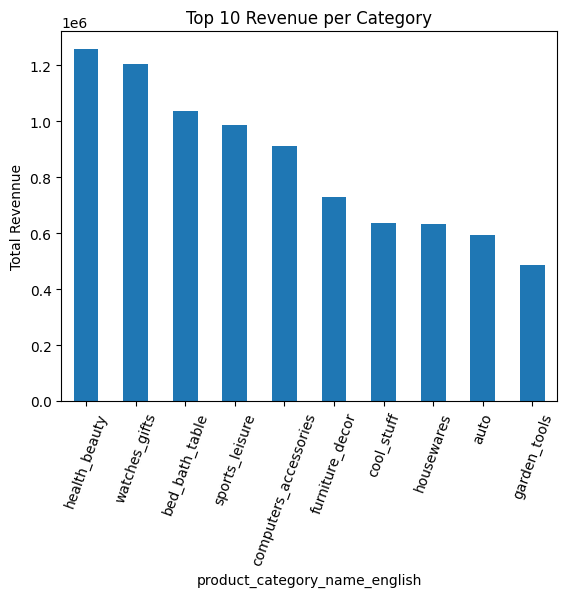

In [15]:
revenue_per_category.head(10).plot(kind='bar')
plt.title('Top 10 Revenue per Category')
plt.ylabel('Total Revennue')
plt.xticks(rotation=70)
plt.show()

mungkin bisa kita bikin table distrubusi harga untuk liat outlier dll biar ada insight fikit

### Pertanyaan 2:

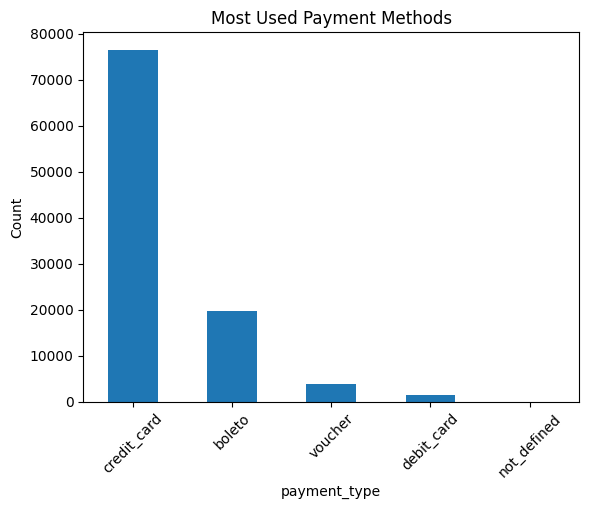

In [31]:
payment_counts.plot(kind='bar')
plt.title('Most Used Payment Methods')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Insight:**
- xxx
- xxx

### Pertanyaan 3

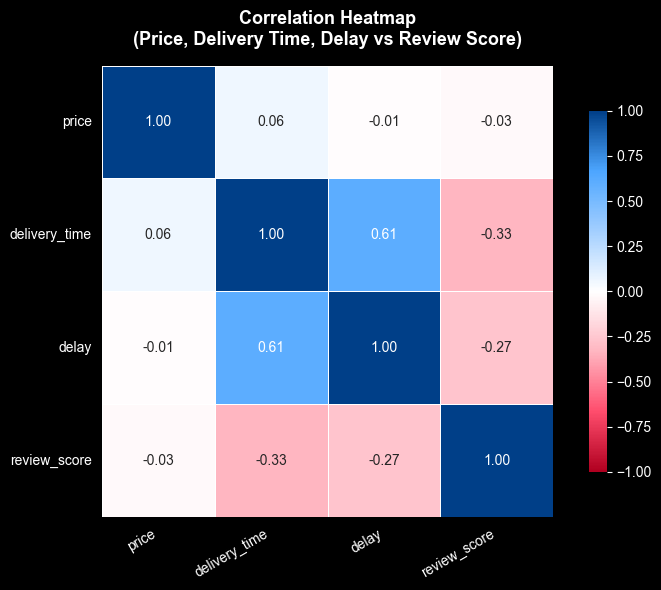

In [16]:
# Heatmap Korelasi
# custom colormap
colors = [
    "#b00020",  # merah pekat (-1)
    "#ff4d6d",  # merah sedang
    "#ffb6c1",  # merah muda (mendekati 0 dari negatif)
    "#ffffff",  # putih (0)
    "#a3cfff",  # biru muda
    "#4da6ff",  # biru
    "#003f88"   # biru pekat (+1)
]

custom_cmap = LinearSegmentedColormap.from_list("custom_corr", colors, N=256)

# heatmap
variables = ['price', 'delivery_time', 'delay', 'review_score']
corr_matrix = df_grouped[variables].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Correlation Heatmap\n(Price, Delivery Time, Delay vs Review Score)",
    fontsize=13, fontweight='bold', pad=15
)

plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

**insight:**
kode diatas merupakan korelasi heatmap antara variable price,
dan terlihat jelas  review score memiliki korelasi negatid tertinggi dari semua pesaing nya yaitu senilai -0.33 jadi semakin lama waktu delivery nya makin menurun review score nya walaupun korelasi nya masih tergolong kecil

<Axes: ylabel='product_category_name_english'>

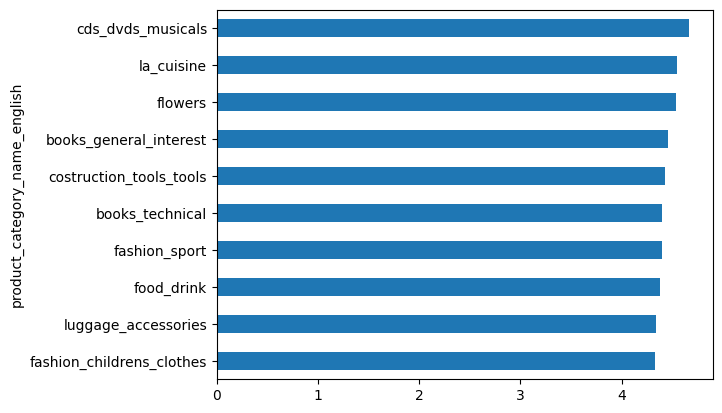

In [53]:
df_grouped.groupby('product_category_name_english')['review_score'].mean().sort_values().tail(10).plot(kind='barh')

## Analisis Lanjutan (Opsional)

### RFM Analysis
bertujuan mengelompokkan pelanggan berdasarkan perilaku pembelian mereka dengan memperhatikan tiga faktor utama:
Recency: Menghitung jumlah hari sejak terakhir kali pelanggan melakukan pembelian.
Frequency: Menghitung jumlah total transaksi yang dilakukan oleh pelanggan dalam periode tertentu.
Monetary: Menghitung total pengeluaran pelanggan dalam periode tersebut.

#### Recency

#### Frequency

#### Monetery

### Geospatial Analysis
bertujuan menganalisis data berdasarkan lokasi geografis untuk mengidentifikasi tren atau pola tertentu di suatu wilayah

### Clustering Manual
bertujuan mengelompokkan data ke dalam grup berdasarkan karakteristik tertentu tanpa menggunakan algoritma machine learning

## Conclusion

### Conclution pertanyaan 1 Kategori Produk apa yang paling banyak menghasilkan revenue? :
 dapat disimpulkan bahwa:

Revenue dipengaruhi oleh dua faktor utama:

- Harga produk
- Volume transaksi

Terdapat 3 pola kategori:

- **High Revenue + High Volume → health_beauty**
- **High Price + Lower Volume → watches_gifts**
- **High Volume + Lower Price → bed_bath_table**

 Kesimpulan Bisnis

- Tidak semua kategori dengan harga tinggi menghasilkan revenue tertinggi
- Kategori dengan kombinasi harga moderat dan volume tinggi cenderung lebih optimal dalam menghasilkan revenue

Strategi bisnis dapat dibagi menjadi:

- **Mass market → fokus volume** *(contoh: bed_bath_table)*
- **Premium market → fokus margin** *(contoh: watches_gifts)*

 ---

### Conclution pertanyaan 2 Metode pembayaran apa yang paling sering digunakan? :

**Dominasi metode pembayaran**

Metode pembayaran **credit_card** sangat mendominasi dibandingkan metode lainnya, dengan selisih yang cukup jauh dari posisi kedua (**boleto**).

Hal ini mengindikasikan bahwa:

- Pengguna cenderung lebih nyaman menggunakan kartu kredit
- Kemungkinan adanya faktor seperti kemudahan transaksi, cicilan, atau promo yang membuat metode ini lebih populer

 **Distribusi Tidak Seimbang** (Imbalance)

 Distribusi metode pembayaran terlihat sangat tidak seimbang (*imbalanced*)

- **credit_card ≫ metode lainnya**
- Gap sangat besar terutama dengan **voucher** dan **debit_card**

 **Implikasi:**

Jika digunakan untuk *machine learning* (classification):

- Model bisa bias ke **credit_card**

Perlu teknik seperti:

- **Oversampling** (SMOTE)
- **Undersampling**
- **Class weighting**

---

### Conclution pertanyaan 3 Faktor apa yang mempengaruhi kepuasan customer? :

Dari seluruh faktor yang dianalisis, delivery time merupakan faktor yang paling berpengaruh terhadap kepuasan pelanggan, dibandingkan harga maupun keterlambatan pengiriman.

 Ranking pengaruh:
Delivery Time → paling berpengaruh
Delay → cukup berpengaruh
Price → hampir tidak berpengaruh
Kesimpulan Bisnis
- Kepuasan pelanggan tidak ditentukan oleh harga
- Faktor utama adalah pengalaman pengiriman
- Semakin lama waktu pengiriman → semakin rendah kepuasan
- Perusahaan sebaiknya fokus pada:
- optimasi logistik
- percepatan delivery